In [1]:
# =========================================================
# ARTIFICIAL NEURAL NETWORK PROJECT
# Iris Flower Classification using TensorFlow/Keras
# Demonstrates:
# - Forward Propagation
# - Backward Propagation
# - Activation Functions
# - Optimizer Comparison
# =========================================================


In [2]:
# =========================================================
# 1. Import Required Libraries
# =========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset and preprocessing tools
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# Evaluation metrics
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Deep Learning libraries
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

print("Libraries imported successfully!")


Libraries imported successfully!


In [3]:
# =========================================================
# 2. Load the Iris Dataset
# =========================================================
# Iris dataset contains 150 samples of flowers
# Each sample has 4 features:
# - sepal length
# - sepal width
# - petal length
# - petal width
#
# Target classes:
# 0 = Setosa
# 1 = Versicolor
# 2 = Virginica

iris = load_iris()

# Convert dataset to pandas dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Add target label column
df["species"] = iris.target

print("Dataset shape:", df.shape)
df.head()



Dataset shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
# =========================================================
# 3. Separate Features and Labels
# =========================================================

# Features (input)
X = df.drop("species", axis=1)

# Labels (output)
y = df["species"]

# Convert labels to one-hot encoding
# Example: 1 -> [0 1 0]
y_categorical = to_categorical(y)

print("Flower classes:", iris.target_names)


Flower classes: ['setosa' 'versicolor' 'virginica']


In [5]:
# =========================================================
# 4. Normalize Features
# =========================================================
# Neural networks work better when features are scaled

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [6]:
# =========================================================
# 5. Split Dataset into Train and Test
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_categorical,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (120, 4)
Testing samples: (30, 4)


In [7]:
# =========================================================
# 6. Function to Build ANN Model
# =========================================================
# This function allows testing different
# activation functions and optimizers

def build_model(activation_function, optimizer_name):

    model = Sequential([

        # Input layer
        Input(shape=(X_train.shape[1],)),

        # Hidden Layer 1
        Dense(16, activation=activation_function),

        # Hidden Layer 2
        Dense(8, activation=activation_function),

        # Output layer (3 classes)
        Dense(3, activation="softmax")
    ])

    # Compile model
    model.compile(
        optimizer=optimizer_name,
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


print("Model builder ready!")



Model builder ready!


In [8]:
# =========================================================
# 6b. Raw Equations: Activation Functions & Optimizers
# =========================================================
# Instead of using Keras built-ins, we implement the
# mathematical equations from scratch using NumPy.

# --- Activation Functions & their Derivatives ---

# ReLU: f(x) = max(0, x)
def relu(x):
    return np.maximum(0, x)

def relu_deriv(x):
    return (x > 0).astype(float)

# Tanh: f(x) = (e^x - e^-x) / (e^x + e^-x)
def tanh(x):
    return (np.exp(x) - np.exp(-x)) / (np.exp(x) + np.exp(-x))

def tanh_deriv(x):
    return 1 - tanh(x) ** 2

# Sigmoid: f(x) = 1 / (1 + e^-x)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

# Softmax: f(x_i) = e^x_i / sum(e^x_j)
def softmax(x):
    e = np.exp(x - np.max(x, axis=1, keepdims=True))
    return e / e.sum(axis=1, keepdims=True)

ACTIVATIONS = {
    'relu':    (relu,    relu_deriv),
    'tanh':    (tanh,    tanh_deriv),
    'sigmoid': (sigmoid, sigmoid_deriv),
}

# --- Loss: Categorical Cross-Entropy ---
# L = -sum(y * log(y_hat))
def cross_entropy(y_hat, y):
    return -np.mean(np.sum(y * np.log(y_hat + 1e-9), axis=1))

# --- Forward Pass ---
def forward(X, W1, b1, W2, b2, W3, b3, act_fn):
    z1 = X @ W1 + b1
    a1 = act_fn(z1)
    z2 = a1 @ W2 + b2
    a2 = act_fn(z2)
    z3 = a2 @ W3 + b3
    a3 = softmax(z3)
    return z1, a1, z2, a2, z3, a3

# --- Backward Pass ---
def backward(X, y, z1, a1, z2, a2, a3, W2, W3, act_deriv):
    m = X.shape[0]
    dz3 = a3 - y                          # softmax + cross-entropy gradient
    dW3 = a2.T @ dz3 / m
    db3 = dz3.mean(axis=0)
    dz2 = (dz3 @ W3.T) * act_deriv(z2)
    dW2 = a1.T @ dz2 / m
    db2 = dz2.mean(axis=0)
    dz1 = (dz2 @ W2.T) * act_deriv(z1)
    dW1 = X.T @ dz1 / m
    db1 = dz1.mean(axis=0)
    return dW1, db1, dW2, db2, dW3, db3

# --- Optimizer Update Rules ---

# SGD: w = w - lr * grad
def sgd_update(params, grads, state, lr=0.01, **kw):
    return [p - lr * g for p, g in zip(params, grads)], state

# RMSProp: v = rho*v + (1-rho)*grad^2 ; w = w - lr*grad / sqrt(v + eps)
def rmsprop_update(params, grads, state, lr=0.001, rho=0.9, eps=1e-8, **kw):
    if not state:
        state = [np.zeros_like(p) for p in params]
    new_state, new_params = [], []
    for p, g, v in zip(params, grads, state):
        v = rho * v + (1 - rho) * g ** 2
        new_state.append(v)
        new_params.append(p - lr * g / (np.sqrt(v) + eps))
    return new_params, new_state

# Adam: m = b1*m + (1-b1)*g ; v = b2*v + (1-b2)*g^2
#       m_hat = m/(1-b1^t) ; v_hat = v/(1-b2^t)
#       w = w - lr * m_hat / (sqrt(v_hat) + eps)
def adam_update(params, grads, state, lr=0.001, b1=0.9, b2=0.999, eps=1e-8, **kw):
    if not state:
        state = {'m': [np.zeros_like(p) for p in params],
                 'v': [np.zeros_like(p) for p in params],
                 't': 0}
    state['t'] += 1
    t = state['t']
    new_params = []
    for i, (p, g) in enumerate(zip(params, grads)):
        state['m'][i] = b1 * state['m'][i] + (1 - b1) * g
        state['v'][i] = b2 * state['v'][i] + (1 - b2) * g ** 2
        m_hat = state['m'][i] / (1 - b1 ** t)
        v_hat = state['v'][i] / (1 - b2 ** t)
        new_params.append(p - lr * m_hat / (np.sqrt(v_hat) + eps))
    return new_params, state

OPTIMIZERS = {'sgd': sgd_update, 'rmsprop': rmsprop_update, 'adam': adam_update}

# --- Train one configuration ---
def train_raw(X_tr, y_tr, X_val, y_val, act_name, opt_name,
              epochs=200, lr=0.01):
    np.random.seed(42)
    n_in, h1, h2, n_out = X_tr.shape[1], 16, 8, y_tr.shape[1]
    W1 = np.random.randn(n_in, h1) * 0.1
    b1 = np.zeros(h1)
    W2 = np.random.randn(h1, h2) * 0.1
    b2 = np.zeros(h2)
    W3 = np.random.randn(h2, n_out) * 0.1
    b3 = np.zeros(n_out)

    act_fn, act_deriv = ACTIVATIONS[act_name]
    opt_fn = OPTIMIZERS[opt_name]
    params = [W1, b1, W2, b2, W3, b3]
    state  = {}

    val_losses, val_accs = [], []
    for _ in range(epochs):
        z1,a1,z2,a2,z3,a3 = forward(X_tr, *params, act_fn)
        grads = backward(X_tr, y_tr, z1,a1,z2,a2,a3,
                         params[2], params[4], act_deriv)
        params, state = opt_fn(params, grads, state, lr=lr)
        _,_,_,_,_,a3v = forward(X_val, *params, act_fn)
        val_losses.append(cross_entropy(a3v, y_val))
        val_accs.append((a3v.argmax(1) == y_val.argmax(1)).mean())

    return params, val_losses, val_accs

print('Raw-equation helpers defined.')


Raw-equation helpers defined.


In [9]:
# =========================================================
# 7. Train Models with Different Activations & Optimizers
# =========================================================

activations = ["relu", "tanh", "sigmoid"]
optimizers = ["adam", "sgd", "rmsprop"]

# Store results
histories = {}
accuracies = {}

best_model = None
best_score = 0        # Best validation accuracy
best_loss = float('inf')  # To break ties using lowest validation loss
best_config = None


for act in activations:
    for opt in optimizers:

        config = f"{act}-{opt}"

        print("\n===================================")
        print("Training Model:", config)
        print("===================================")

        model = build_model(act, opt)

        # Early stopping prevents overfitting
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=10,
            restore_best_weights=True
        )

        # Train model (forward + backward propagation)
        history = model.fit(
            X_train,
            y_train,
            validation_data=(X_test, y_test),
            epochs=100,
            batch_size=8,
            callbacks=[early_stop],
            verbose=0
        )

        # Store history
        histories[config] = history

        # Extract metrics
        train_acc = max(history.history["accuracy"])
        val_acc = max(history.history["val_accuracy"])

        train_loss = min(history.history["loss"])
        val_loss = min(history.history["val_loss"])

        # Print results for each model
        print("Training Accuracy :", round(train_acc,4))
        print("Validation Accuracy :", round(val_acc,4))
        print("Training Loss :", round(train_loss,4))
        print("Validation Loss :", round(val_loss,4))

        # Track best model:
        # 1️⃣ First by validation accuracy
        # 2️⃣ If tie, by lowest validation loss
        if (val_acc > best_score) or (val_acc == best_score and val_loss < best_loss):
            best_score = val_acc
            best_loss = val_loss
            best_model = model
            best_config = config


print("\n==============================")
print("Best Model Configuration:", best_config)
print("Best Validation Accuracy:", round(best_score,4))
print("Best Validation Loss:", round(best_loss,4))
print("==============================")


Training Model: relu-adam
Training Accuracy : 0.9917
Validation Accuracy : 1.0
Training Loss : 0.0524
Validation Loss : 0.0353

Training Model: relu-sgd
Training Accuracy : 0.9583
Validation Accuracy : 0.9667
Training Loss : 0.1577
Validation Loss : 0.1058

Training Model: relu-rmsprop
Training Accuracy : 0.9833
Validation Accuracy : 1.0
Training Loss : 0.0542
Validation Loss : 0.0209

Training Model: tanh-adam
Training Accuracy : 0.975
Validation Accuracy : 1.0
Training Loss : 0.0659
Validation Loss : 0.0464

Training Model: tanh-sgd
Training Accuracy : 0.95
Validation Accuracy : 0.9667
Training Loss : 0.1401
Validation Loss : 0.117

Training Model: tanh-rmsprop
Training Accuracy : 0.9833
Validation Accuracy : 1.0
Training Loss : 0.0543
Validation Loss : 0.0349

Training Model: sigmoid-adam
Training Accuracy : 0.9667
Validation Accuracy : 0.9667
Training Loss : 0.2418
Validation Loss : 0.2297

Training Model: sigmoid-sgd
Training Accuracy : 0.85
Validation Accuracy : 0.9333
Training 

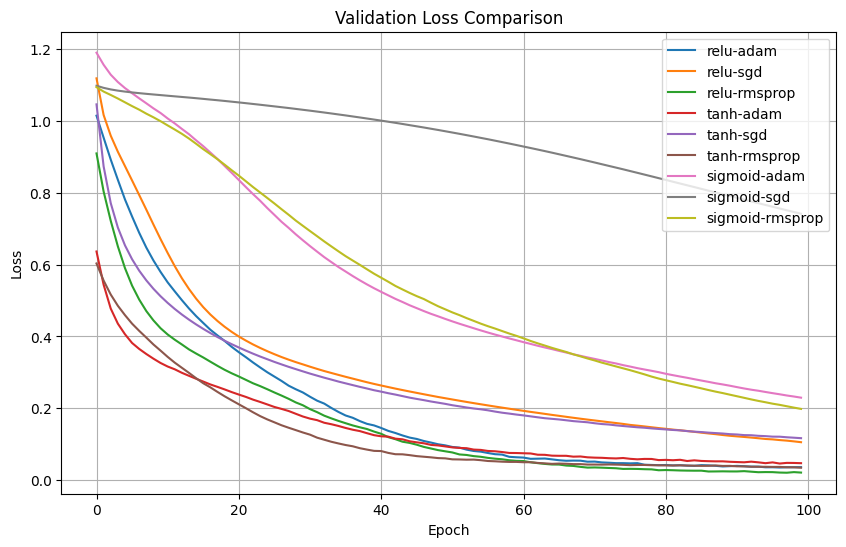

In [10]:
# =========================================================
# 8. Plot Validation Loss for All Configurations
# =========================================================

plt.figure(figsize=(10,6))

for config in histories:
    plt.plot(histories[config].history["val_loss"], label=config)

plt.title("Validation Loss Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()


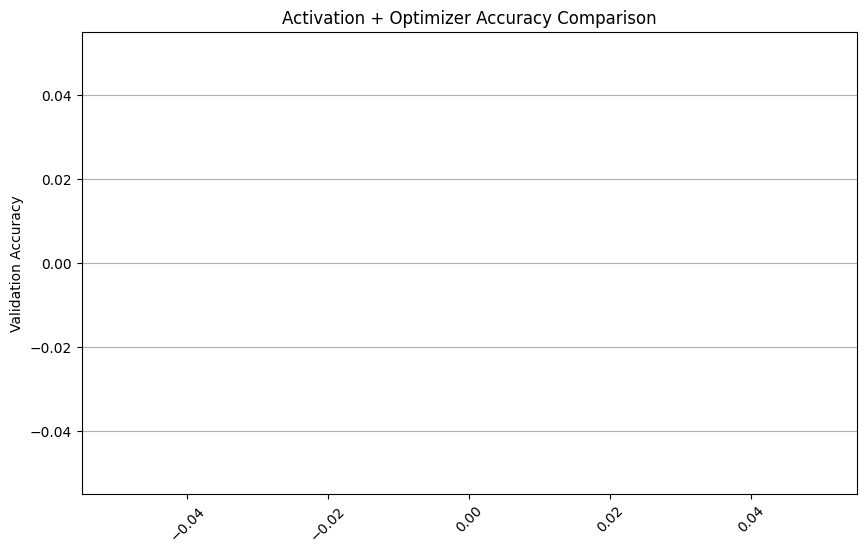

In [11]:
# =========================================================
# 9. Compare Validation Accuracy
# =========================================================

plt.figure(figsize=(10,6))

plt.bar(accuracies.keys(), accuracies.values())

plt.xticks(rotation=45)

plt.title("Activation + Optimizer Accuracy Comparison")
plt.ylabel("Validation Accuracy")

plt.grid(axis="y")

plt.show()


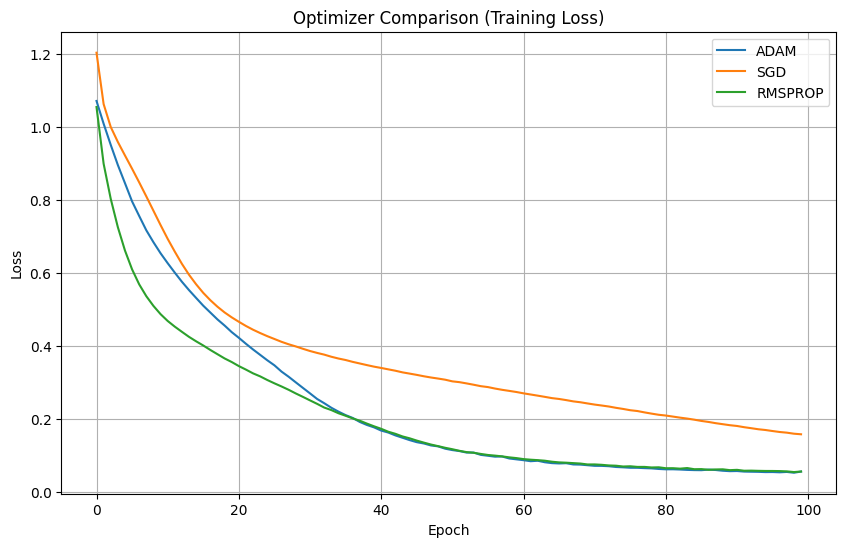

In [12]:
# =========================================================
# 10. Optimizer Training Loss Visualization
# =========================================================
# Shows how optimizers converge

plt.figure(figsize=(10,6))

for config in histories:

    act, opt = config.split("-")

    # Only show RELU optimizer comparison
    if act == "relu":

        plt.plot(
            histories[config].history["loss"],
            label=opt.upper()
        )

plt.title("Optimizer Comparison (Training Loss)")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()
plt.grid(True)

plt.show()

In [13]:
# =========================================================
# 11. Evaluate Best Model
# =========================================================

y_pred_prob = best_model.predict(X_test)

y_pred = np.argmax(y_pred_prob, axis=1)
y_true = np.argmax(y_test, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step


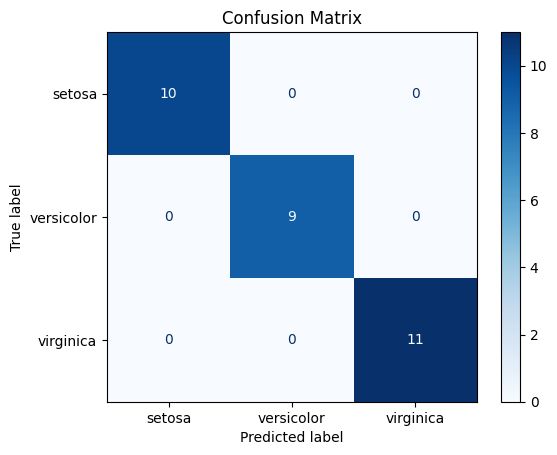

In [18]:
# 12. Confusion Matrix
# =========================================================

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=iris.target_names
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

In [15]:
# =========================================================
# 13. Classification Report
# =========================================================

print("Classification Report:\n")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=iris.target_names
    )
)

Classification Report:

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00         9
   virginica       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [16]:
# =========================================================
# Manual Hard-coded Prediction
# ---------------------------------------------------------
# Provide a custom flower measurement and let the model
# predict which Iris species it belongs to.
# =========================================================

custom_values = [5.1, 3.5, 1.4, 0.2]

custom_input = np.array(custom_values).reshape(1, -1)

# Apply same scaling used during training
custom_input_scaled = scaler.transform(custom_input)

prediction = best_model.predict(custom_input_scaled)

predicted_index = np.argmax(prediction)

predicted_label = iris.target_names[predicted_index]

print("\n==============================")
print(" Iris Flower Prediction ")
print("==============================")

print("\nGiven Input:")

for name, val in zip(X.columns, custom_values):
    print(f"{name}: {val}")

print("\nPredicted Flower:", predicted_label)

print("\nPrediction Probabilities:")

for cls, prob in zip(iris.target_names, prediction[0]):
    print(f"{cls}: {prob:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step

 Iris Flower Prediction 

Given Input:
sepal length (cm): 5.1
sepal width (cm): 3.5
petal length (cm): 1.4
petal width (cm): 0.2

Predicted Flower: setosa

Prediction Probabilities:
setosa: 1.0000
versicolor: 0.0000
virginica: 0.0000


C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


3759/3759 ━━━━━━━━━━━━━━━━━━━━ 3s 739us/step


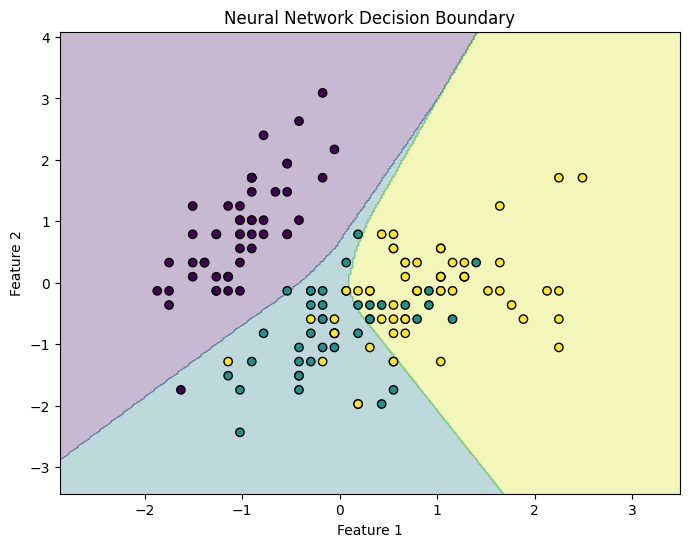

In [17]:
# =========================================================
# 15. Decision Boundary Visualization
# =========================================================
# Use only first two features for visualization

X_vis = X_scaled[:, :2]

X_train_vis, X_test_vis, y_train_vis, y_test_vis = train_test_split(
    X_vis,
    y_categorical,
    test_size=0.2,
    random_state=42
)

model_vis = Sequential([
    Input(shape=(2,)),
    Dense(16, activation="relu"),
    Dense(8, activation="relu"),
    Dense(3, activation="softmax")
])

model_vis.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model_vis.fit(X_train_vis, y_train_vis, epochs=100, verbose=0)

# Create mesh grid
x_min, x_max = X_vis[:,0].min()-1, X_vis[:,0].max()+1
y_min, y_max = X_vis[:,1].min()-1, X_vis[:,1].max()+1

xx, yy = np.meshgrid(
    np.arange(x_min, x_max, 0.02),
    np.arange(y_min, y_max, 0.02)
)

grid = np.c_[xx.ravel(), yy.ravel()]

pred = model_vis.predict(grid)

pred = np.argmax(pred, axis=1)
pred = pred.reshape(xx.shape)

plt.figure(figsize=(8,6))

plt.contourf(xx, yy, pred, alpha=0.3)

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y,
    edgecolor="k"
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")

plt.title("Neural Network Decision Boundary")

plt.show()